## Assignment 1 - Deadline: Mar 1, 2026, Sun 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
import time

pd.set_option('display.max_rows', None)

# Problem 1: Training in PyTorch with Boston Housing Dataset (50 pts)
(You have to use PyTorch in this problem, Tensorflow will not be accepted as answer.)

a) Repeat the steps for loading Boston Housing Dataset as done in `Lecture_02.ipnyb`.

b) Train the model with PyTorch only and calculate evaluation metrics as done in `Lecture_02.ipnyb`, except this time you will use the following ANN architecture. (Note: Do not include code for linear regression and tensorflow training.)


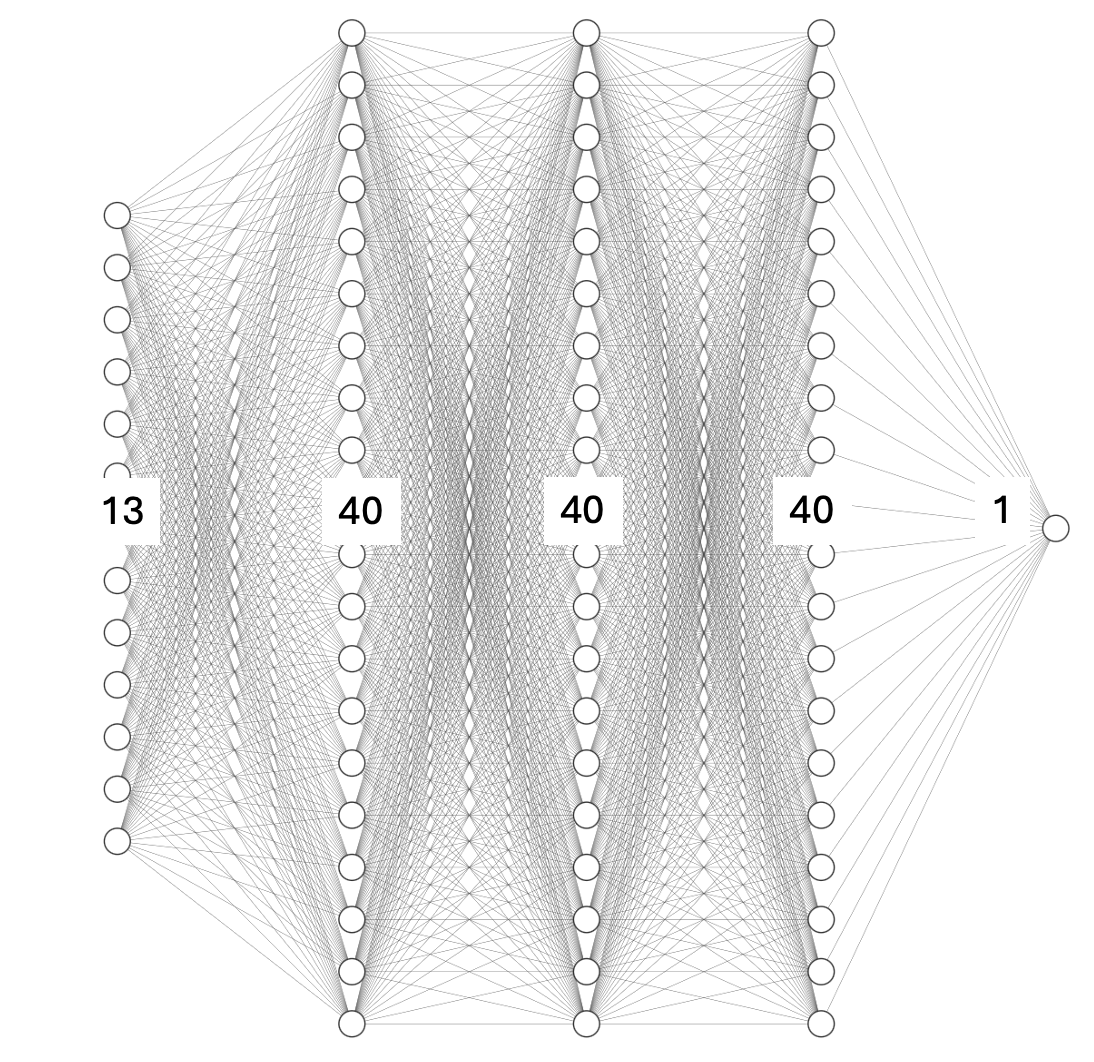

#### Part a)

In [2]:
from tensorflow.keras.datasets import boston_housing

# Load the Boston housing dataset
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

# Combine the data and targets
data = np.concatenate([train_data, test_data])
targets = np.concatenate([train_targets, test_targets])

# Convert to a DataFrame
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=column_names)
df['MDEV'] = targets

# Shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MDEV
501,6.39312,0.0,18.10,0.0,0.584,6.162,97.4,2.2060,24.0,666.0,20.2,302.76,24.10,13.3
502,3.53501,0.0,19.58,1.0,0.871,6.152,82.6,1.7455,5.0,403.0,14.7,88.01,15.02,15.6
503,0.38214,0.0,6.20,0.0,0.504,8.040,86.5,3.2157,8.0,307.0,17.4,387.38,3.13,37.6
504,10.06230,0.0,18.10,0.0,0.584,6.833,94.3,2.0882,24.0,666.0,20.2,81.33,19.69,14.1
505,0.47547,0.0,9.90,0.0,0.544,6.113,58.8,4.0019,4.0,304.0,18.4,396.23,12.73,21.0


In [3]:
# Calculate the number of rows for each set
num_rows = df.shape[0]
train_size = int(num_rows * 0.65)
validation_size = int(num_rows * 0.15)
test_size = num_rows - train_size - validation_size

# Split the DataFrame
train_df = df.iloc[:train_size]
validation_df = df.iloc[train_size:train_size + validation_size]
test_df = df.iloc[train_size + validation_size:]

# Verify the splits
print(f"Total number of rows: {num_rows}")
print(f"Training set size: {train_df.shape[0]}")
print(f"Validation set size: {validation_df.shape[0]}")
print(f"Testing set size: {test_df.shape[0]}")

# Define the targets
train_targets = train_df['MDEV'].values
validation_targets = validation_df['MDEV'].values
test_targets = test_df['MDEV'].values

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data only (to prevent data leakage)
scaler.fit(train_df.drop('MDEV', axis=1))

# Standardize the training, validation, and testing sets
train = scaler.transform(train_df.drop('MDEV', axis=1))
validation = scaler.transform(validation_df.drop('MDEV', axis=1))
test = scaler.transform(test_df.drop('MDEV', axis=1))

Total number of rows: 506
Training set size: 328
Validation set size: 75
Testing set size: 103


#### Part b)

In [4]:
# Convert data to PyTorch tensors
train_tensor = torch.tensor(train, dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets, dtype=torch.float32)
validation_tensor = torch.tensor(validation, dtype=torch.float32)
validation_targets_tensor = torch.tensor(validation_targets, dtype=torch.float32)
test_tensor = torch.tensor(test, dtype=torch.float32)
test_targets_tensor = torch.tensor(test_targets, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(train_tensor, train_targets_tensor)
validation_dataset = TensorDataset(validation_tensor, validation_targets_tensor)
test_dataset = TensorDataset(test_tensor, test_targets_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the model with architecture (13, 40, 40, 40, 1)
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.layer1 = nn.Linear(train.shape[1], 40)
        self.layer2 = nn.Linear(40, 40)
        self.layer3 = nn.Linear(40, 40)
        self.output_layer = nn.Linear(40, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = self.output_layer(x)
        return x

# Loss function
loss_fn = nn.MSELoss()

# Training function
def train_model(model, train_loader, validation_loader, optimizer, loss_fn, epochs=100):
    train_losses = []
    validation_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets.view(-1, 1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_mse = train_loss / len(train_loader)
        train_losses.append(train_mse)

        model.eval()
        validation_loss = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs, targets.view(-1, 1))
                validation_loss += loss.item()
        validation_mse = validation_loss / len(validation_loader)
        validation_losses.append(validation_mse)

        print(f'Epoch {epoch+1}/{epochs}, Train MSE: {train_mse:.4f}, Validation MSE: {validation_mse:.4f}')

    return train_losses, validation_losses

# Initialize model and optimizer
def initialize_model_and_optimizer():
    model = RegressionModel()
    optimizer = torch.optim.RMSprop(
        model.parameters(),
        lr=0.001,
        alpha=0.9,
        eps=1e-7,
        momentum=0.0,
        centered=False)
    return model, optimizer

# Train
model, optimizer = initialize_model_and_optimizer()

start_time = time.time()
train_losses, validation_losses = train_model(model, train_loader, validation_loader, optimizer, loss_fn, epochs=100)
end_time = time.time()

print(f"\nTotal training time: {end_time - start_time:.2f} seconds")

Epoch 1/100, Train MSE: 551.5199, Validation MSE: 536.4656
Epoch 2/100, Train MSE: 511.5904, Validation MSE: 481.0693
Epoch 3/100, Train MSE: 444.3773, Validation MSE: 382.8667
Epoch 4/100, Train MSE: 336.6505, Validation MSE: 255.8594
Epoch 5/100, Train MSE: 223.8341, Validation MSE: 130.7412
Epoch 6/100, Train MSE: 119.2869, Validation MSE: 60.9226
Epoch 7/100, Train MSE: 73.7837, Validation MSE: 37.0691
Epoch 8/100, Train MSE: 58.2703, Validation MSE: 29.7896
Epoch 9/100, Train MSE: 47.1558, Validation MSE: 20.5229
Epoch 10/100, Train MSE: 38.7054, Validation MSE: 18.2270
Epoch 11/100, Train MSE: 41.0174, Validation MSE: 16.7491
Epoch 12/100, Train MSE: 31.8223, Validation MSE: 13.8690
Epoch 13/100, Train MSE: 27.8949, Validation MSE: 11.5859
Epoch 14/100, Train MSE: 26.3706, Validation MSE: 12.6831
Epoch 15/100, Train MSE: 23.9339, Validation MSE: 11.9254
Epoch 16/100, Train MSE: 23.2239, Validation MSE: 10.6416
Epoch 17/100, Train MSE: 24.7810, Validation MSE: 10.7292
Epoch 18/100

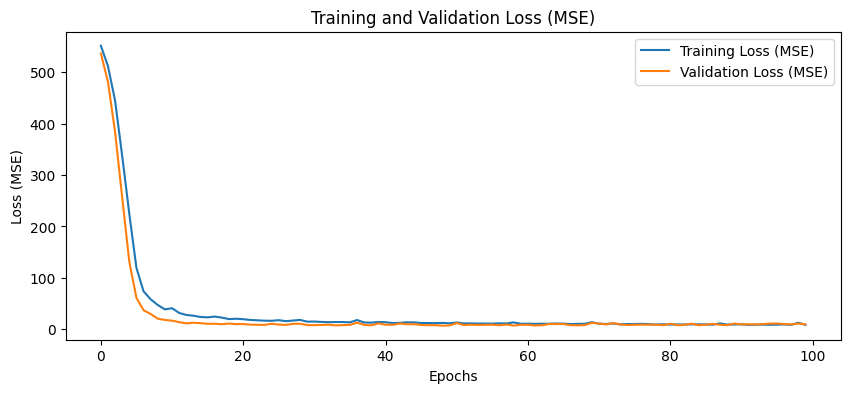

Test MAE: 2.3
Test MAPE: 10.6%


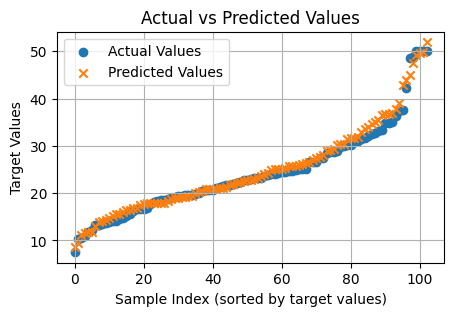

In [5]:
# Plot training and validation loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss (MSE)')
plt.plot(validation_losses, label='Validation Loss (MSE)')
plt.title('Training and Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Evaluate model performance on the test set
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        all_preds.append(outputs)
        all_targets.append(targets)

# Concatenate all batches
y_pred = torch.cat(all_preds).cpu().numpy().flatten()
y_true = torch.cat(all_targets).cpu().numpy().flatten()

# MAE
mae = mean_absolute_error(y_true, y_pred)

# MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"Test MAE: {mae:.1f}")
print(f"Test MAPE: {mape:.1f}%")

# Plot actual vs predicted
y_test_sorted = np.sort(y_true)
y_pred_sorted = np.sort(y_pred)

plt.figure(figsize=(5, 3))
plt.scatter(range(len(y_test_sorted)), y_test_sorted, label='Actual Values', marker='o')
plt.scatter(range(len(y_pred_sorted)), y_pred_sorted, label='Predicted Values', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index (sorted by target values)')
plt.ylabel('Target Values')
plt.legend()
plt.grid(True)
plt.show()